In [7]:
import pandas as pd #  היא ספרייה לעבודה עם נתונים טבלאיים - Pandas
import numpy as np #  היא ספרייה לעבודה עם מערכים מספריים (Arrays) וחישובים מתמטיים מהירים- NumPy
import matplotlib.pyplot as plt # זו ספריית הציור
import seaborn as sns #  כדי לצייר, אבל מספקת ממשק נוח יותר וגרפים שנראים טוב כברירת  , Seaborn משתמשת ב-Matplotlib
from sklearn.datasets import load_breast_cancer


חשוב להבין:

אף אחת מהספריות האלה לא מבצעת Machine Learning.

לפני שמאמנים מודל, צריך לדעת:

1. Load the data.
2. Understand the data.
3. Clean and preprocess the data.
4. Visualize and explore the data.

רק לאחר שכל השלבים האלה הושלמו, נשתמש ב־scikit-learn כדי לבנות, לאמן ולהעריך מודלים של Machine Learning.

כלל חשוב:
**Data first, model second.**

What is a DataFrame?

A DataFrame is the main data structure in Pandas.

It can be thought of as an Excel spreadsheet inside Python.

In [8]:
cancer = load_breast_cancer() #  breast_cancer :יצירת אובייקט שמכיל את כל המידע של

 #  feature_names - ושיוך העמודות לשמות של המאפיינים cancer.data:הנתונים נמצאים ב
#    רק משנה את צורת הייצוג של הנתונים df = pd.DataFrame(...) השורה
df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



** head שימוש בפונקצייה של **
  
   כדי לקבל מבט ראשון על הנתונים.


אנחנו רוצים לענות על שאלות כמו:

האם הנתונים נטענו כמו שצריך?
אילו עמודות קיימות?
האם הערכים נראים הגיוניים?
האם יש ערכים חסרים או מוזרים?

In [ ]:
df.shape # (עמודות,שורות)

#  שורות 569 → יש לנו 569 דוגמאות (מטופלים).
#  עמודות 30 → לכל מטופל יש 30 מאפיינים

(569, 30)

In [9]:
df["target"] = cancer.target # היא להוסיף עמודה חדשה של המטרה כך שלכל מטופל תהיה גם התשובה הנכונה.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**info**

DataFrame- היא נותנת לנו תעודת זהות של ה

היא עונה על שאלות כמו:

כמה שורות יש?
כמה עמודות יש?
מה השם של כל עמודה?
איזה סוג נתונים יש בכל עמודה?
האם יש ערכים חסרים (Missing Values)?
כמה זיכרון הטבלה תופסת?

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

**הסבר על ערכי הטבלה:**

count - מספר הערכים בעמודה.

mean  - הממוצע של כל הערכים.

std   - סטיית התקן (מידת הפיזור של הערכים סביב הממוצע).

min   - הערך הקטן ביותר.

25%   - רבע מהערכים קטנים מהערך הזה.

50%   - החציון (Median).

75%   - 75% מהערכים קטנים מהערך הזה.

max   - הערך הגדול ביותר.

In [11]:
df.describe() # היא מחזירה סיכום סטטיסטי לכל עמודה מספרית

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [12]:
df["target"].value_counts() # כמה מטופלים הם ממאירים וכמה הם שפירים

# בודקים אם הדוגמואת בערך מאוזנות אחרת הוא פשוט ינחס את המחלקה עם המספר דוגמואת הרב יותר ולא באמת ילמד

,count
target,
1,357
0,212


In [13]:
df.isnull().sum() #  דרך הרבה יותר נוחה לבדוק האם יש עמודות בעייתיות - שאין לה ערכים

# אם יצא 0 אז הכל בסדר אם 1 אז לא טוב ויש עמודה בעייתית

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


השלמת ערכים:

**אם חסר ערך- נשלים בעזרת ממוצע **

df["@@"] = df["@@"].fillna(df["@@"].mean())

אם יש גם  ערך קיצוני- נשלים בעזרת חציון

df["@@"] = df["@@"].fillna(df["@@"].median())

**@@ זה שם העמודה הבעייתית **

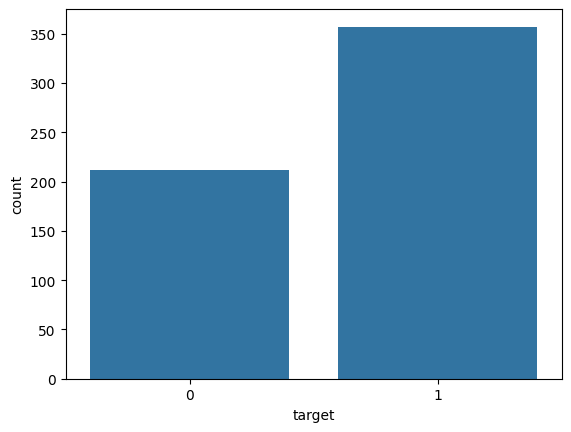

In [14]:
sns.countplot(x="target", data=df) # זה סוג של גרף שסופר כמה פעמים מופיע כל ערך
plt.show()

In [15]:
X = df.drop("target", axis=1) # הפרדת רק של המאפיינים. 1 מסמן עמודות, 0 שורות
y = df["target"]

In [16]:
from sklearn.model_selection import train_test_split # פונקצייה שמאפשרת לחלק את הנתונים לאימון ולמידה

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # אחוז שהמודל לא ילמד ויבחן את עצמו עליו
    random_state=42 # אפשר לקחת כל מספר, צריך את זה  שכל מי שיריץ את הקוד יקבל בדיוק את אותה חלוקה ואת אותן תוצאות

)

In [17]:
X_train.shape # הנתונים ללמידה

(455, 30)

In [18]:
X_test.shape # הנתונים לבחינה

(114, 30)

שתי השורות שמעליי הם בדיקה. אם יש לי 569 נתונים סך הכל אני צריך לוודא שהם מתחלקים לשתי הקבוצות

--------------------------------------------------------------------------------

# מודל ראשון – Logistic Regression

- אלגוריתם ללמידה מונחית (Supervised Learning).
- מיועד לבעיות סיווג (Classification).
- לומד את הקשר בין המאפיינים לבין התוצאה.
- מחשב הסתברות להשתייכות לכל מחלקה.
- מסווג את הדוגמה ל-0 או ל-1.

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() # יצירת המודל

model.fit(X_train, y_train) # אימון המודל

# אחרי שהאימון מסתיים, המודל מוכן לקבל נתונים חדשים ולבצע חיזוי.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [20]:
model.predict(X_test) # התחזית שהוא נתן לכל מטופל

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [21]:
y_test.values # התשובה האמיתית

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

דרך נוחה לראות אם באמת החיזוי שווה לאמת

In [22]:
 y_pred = model.predict(X_test)
 comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


In [23]:
from sklearn.metrics import accuracy_score # היא פונקציה שמחשבת את אחוז התחזיות הנכונות של המודל.

accuracy = accuracy_score(y_test, y_pred) #  חישוב הדיוק בין התוצאה האמיתי לחיזוי כמה צדק

print(f"the accuracy is: {accuracy*100:.2f}%" ) # 2f זה ספרות אחרי הנק

the accuracy is: 95.61%


# Confusion Matrix

לאחר שחישבנו את ה-Accuracy, נרצה להבין טוב יותר את ביצועי המודל.

Confusion Matrix מציגה השוואה בין הערכים האמיתיים לבין התחזיות של המודל.

באמצעותה ניתן לראות:
- כמה דוגמאות סווגו נכון.
- כמה דוגמאות סווגו בצורה שגויה.
- איזה סוג של טעויות המודל ביצע.

בבעיית סיווג בינארית נקבל מטריצה בגודל 2×2.

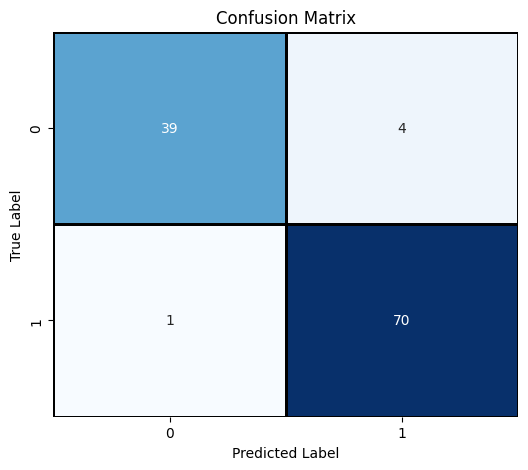

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,          # מציג את המספרים בתוך התאים
    fmt="d",             # הצגת מספרים שלמים
    cmap="Blues",        # מפת צבעים כחולה
    linewidths=1,        # קווי הפרדה בין התאים
    linecolor="black",   # צבע קווי ההפרדה
    cbar=False           # הסתרת סרגל הצבעים
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

---
# 📋 Model Evaluation – Classification Report

לאחר שבדקנו את ה-Accuracy וניתחנו את ה-Confusion Matrix, נרצה לקבל תמונה מלאה יותר על ביצועי המודל.

**Classification Report** מרכז מספר מדדי הערכה חשובים עבור כל מחלקה:

- **Precision** – מתוך כל התחזיות של המודל למחלקה מסוימת, כמה היו נכונות.
- **Recall** – מתוך כל הדוגמאות האמיתיות במחלקה, כמה המודל הצליח לזהות.
- **F1-Score** –  זה איזון בין השתייים העליונים. ממוצע בינהם F1
- **Support** – מספר הדוגמאות האמיתיות מכל מחלקה.

אני מתייחס לכל מחלקה באופן שווה, בלי קשר לכמה דוגמאות יש בה.- Macro Average

  מחלקות גדולות מקבלות יותר משקל. - Weighted Average

מדדים אלו מאפשרים להבין את איכות המודל בצורה מעמיקה יותר מאשר Accuracy בלבד.

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



--------------------------------------------------------------------------------

---
# 🌳 מודל 2 – Decision Tree

 הוא מודל שלומד לקבל החלטות באמצעות מבנה דמוי עץ.Decision Tree

בכל צומת בעץ נשאלת שאלה על אחד המאפיינים (Features), והתשובה קובעת לאיזה ענף נמשיך. לאחר סדרת החלטות, המודל מגיע לעלה בעץ ומחזיר את הסיווג הסופי.

בשלב זה נבנה את המודל, נאמן אותו על אותם הנתונים ונשווה את ביצועיו למודל הקודם.

In [28]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)# יצירת מודל

In [29]:
model.fit(X_train, y_train) # אימון המודל

DecisionTreeClassifier(random_state=42)

In [30]:
y_pred = model.predict(X_test) # ביצוע חיזוי

In [31]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 94.74%


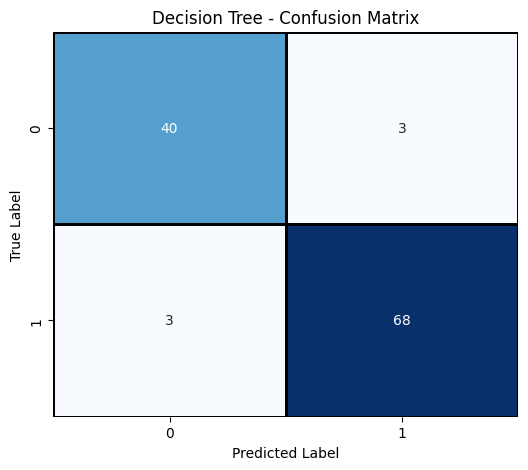

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



--------------------------------------------------------------------------------

---
# 🌲 מודל 3 – Random Forest

Random Forest הוא אלגוריתם המבוסס על אוסף של עצי החלטה (Decision Trees).

במקום להסתמך על עץ יחיד, המודל בונה מספר רב של עצים, כאשר כל עץ מתאמן על חלק שונה מהנתונים.

בסיום התהליך כל העצים מצביעים, והסיווג הסופי נקבע לפי דעת הרוב.

שיטה זו מפחיתה את הסיכון להתאמת יתר (Overfitting) ומשפרת בדרך כלל את יכולת ההכללה של המודל על נתונים חדשים.

בשלב זה נאמן את המודל, נעריך את ביצועיו ונשווה אותם למודלים הקודמים.

In [35]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)

In [36]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
y_pred = model.predict(X_test)

In [38]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 96.49%


In [39]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  3]
 [ 1 70]]


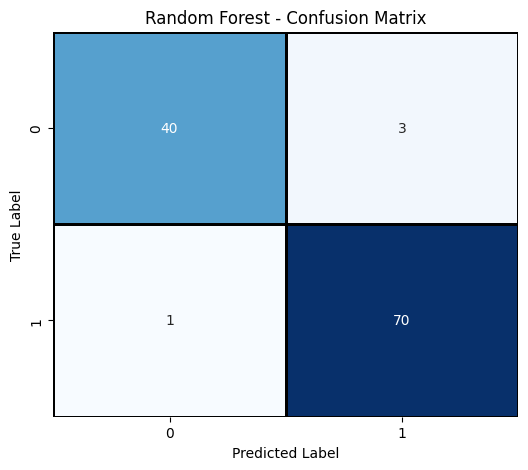

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



 Random Forest כבר עכשיו מתחילים לראות למה קיים בכלל.

Decision Tree  -בונה עץ אחד.

Random Forest - בונה הרבה עצים ומבצע הצבעת רוב ביניהם.

לכן בדרך כלל הוא:

יציב יותר.
פחות רגיש לרעש בנתונים.
פחות נוטה ל-Overfitting.
משיג תוצאות טובות יותר.

וזה בדיוק מה שאנחנו רואים כאן בפועל.

--------------------------------------------------------------------------------


---
# 📈 מודל 4 – Support Vector Machine (SVM)

 הוא אלגוריתם סיווג שמטרתו למצוא את קו ההפרדה Support Vector Machine
 (Decision Boundary) הטוב ביותר בין המחלקות.

המודל מנסה לבחור את קו ההפרדה שמייצר את המרחק הגדול ביותר בין הדוגמאות של כל מחלקה.

במקרים רבים SVM מציג ביצועים גבוהים במיוחד בבעיות סיווג, במיוחד כאשר קיימת הפרדה טובה בין המחלקות.

בשלב זה נאמן את המודל, נעריך את ביצועיו ונשווה אותם למודלים הקודמים.

In [43]:
from sklearn.svm import SVC
model = SVC(random_state=42)

In [44]:
model.fit(X_train, y_train)

SVC(random_state=42)

In [45]:
y_pred = model.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 94.74%


In [47]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[37  6]
 [ 0 71]]


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



מכיוון שבפרויקט הזה אנחנו מריצים את כל המודלים עם הגדרות ברירת המחדל וללא עיבוד נוסף, ההשוואה נשארת הוגנת. בהמשך הלמידה תלמד שכאשר מבצעים Feature Scaling ומכוונים את הפרמטרים, SVM יכול להשתפר משמעותית.

### מסקנות מהתוצאות

במקרה שלנו ה- מודל סיווג בצורה נכונה את כל הדוגמאות השפירות, אך פספס מספר דוגמאות ממאירות.

המשמעות היא שכאשר המודל קבע שדגימה היא ממאירה, הוא כמעט תמיד צדק
(Precision גבוה מאוד), אך הוא לא הצליח לזהות את כל המקרים הממאירים (Recall נמוך יותר).

מהתוצאות ניתן לראות שהמודל העדיף שלא לסווג דגימה כ"ממאירה" אלא אם היה בטוח בכך. כתוצאה מכך, כאשר חזה "ממאיר" הוא כמעט תמיד צדק, אך במקביל פספס חלק מהמקרים הממאירים וסיווג אותם בטעות כ"שפירים".


-----------------------------------------------------------------------------

# 👥 מודל 5 – K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) הוא אלגוריתם סיווג שמבוסס על רעיון פשוט:

**דוגמאות דומות נוטות להשתייך לאותה מחלקה.**

כאשר מתקבלת דגימה חדשה, המודל שואל:

**"לאילו דוגמאות שכבר ראיתי היא הכי דומה?"**

כדי לענות על כך, הוא מחשב את המרחק בין הדגימה החדשה לבין כל הדוגמאות שבנתוני האימון.

לאחר מכן הוא בוחר את המספר של הדוגמאות הקרובות ביותר.

לבסוף, הוא בודק לאיזו מחלקה שייכות אותן דוגמאות, ומסווג את הדגימה החדשה לפי דעת הרוב.

### דוגמה

נניח שהמודל צריך לסווג דגימה חדשה.

הוא בודק את חמש הדוגמאות הקרובות ביותר אליה (K=5).

אם שלוש מהן שייכות למחלקת "שפיר" ושתיים למחלקת "ממאיר", הדגימה החדשה תסווג כ"שפיר", מכיוון שזו דעת הרוב.

In [49]:
from sklearn.neighbors import KNeighborsClassifier # ייבוא
model = KNeighborsClassifier() # יצירת מודל
K = 5 #  כלומר, המודל יסתכל על 5 השכנים הקרובים ביותר.

In [50]:
model.fit(X_train, y_train)

KNeighborsClassifier()

In [52]:
y_pred = model.predict(X_test)
# המודל מחשב את המרחק בין הדגימה החדשה לבין כל דוגמאות האימון.
#בוחר את 5 השכנים הקרובים ביותר.
#מבצע הצבעת רוב.
#מחזיר את הסיווג

y_pred # רק התחזית


array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [53]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 95.61%


In [54]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  5]
 [ 0 71]]


In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

